# Deep Learning - Homework 1

## Extending Demo 1.5 - ML Classification examples

### Marianna Kanellaki
### S-001081

Remote data load (seaborn.load_dataset('titanic'), ~891 samples).

Clean preprocessing via a ColumnTransformer (median / most-frequent imputation + one-hot).

*Four* classical models: Logistic Regression, Random Forest, SVM (RBF with probability=True), and XGBoost.

Timing with time.perf_counter() for both fit and predict.

Metrics: accuracy (primary), precision, recall, f1 score, ROC AUC + curves, confusion matrices.

Plots: test metrics bar, train/predict time bars, ROC curves, per-model confusion matrices.

Sources (docs & datasets)

Seaborn “titanic” dataset (remote load):
https://seaborn.pydata.org/generated/seaborn.load_dataset.html

In [1]:
#!/usr/bin/env python3
"""
Demo 1 — Classical ML for classification (Titanic-like, <=1k rows)
- Loads a small dataset remotely (seaborn 'titanic': ~891 rows)
- Trains Logistic Regression, Random Forest, SVM, XGBoost
- Tracks train & test (inference) time
- Reports accuracy, precision, recall, f1 score and ROC AUC\
- Plots: test metrics bar, fit/predict times, ROC curves, confusion matrices
"""

import time
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

### -----------------------------
### 1) Load remote dataset (<=1k)
### -----------------------------

In [2]:
# seaborn.load_dataset downloads from the public seaborn repo (remote source)
import seaborn as sns
df = sns.load_dataset("titanic")  # ~891 rows

# Select a simple, mostly clean subset of useful columns
use_cols = [
    "survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"
]
df = df[use_cols].copy()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


### -----------------------------
### 2) Basic cleaning
### -----------------------------

In [3]:
# Define target and features
target = "survived"
y = df[target].astype(int).values
X = df.drop(columns=[target])

# Identify column types
num_cols = ["age", "sibsp", "parch", "fare", "pclass"]
cat_cols = ["sex", "embarked"]

# Preprocess: impute missing (median for nums, most_frequent for cats), one-hot encode cats
numeric_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ],
    remainder="drop",
)

# Train/test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### -----------------------------
### 3) Models
### -----------------------------

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=None),  # n_jobs not supported here
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": XGBClassifier(               # added xgboost model
                      scale_pos_weight=1, 
                      learning_rate=0.01,  
                      colsample_bytree = 0.9,
                      subsample = 0.8,
                      objective='binary:logistic', 
                      n_estimators=1000, 
                      reg_alpha = 0.3,
                      max_depth=5, 
                      gamma=1,
                      min_child_weight=6,
                      random_state=42,
                      seed=27
    )
}

results = []
roc_curves = {}  # name -> (fpr, tpr, auc)

### -----------------------------
### 4) Train, time, evaluate
### -----------------------------

In [5]:

for name, base_clf in models.items():
    clf = Pipeline(steps=[("prep", preprocess), ("model", base_clf)])

    # Train time
    t0 = time.perf_counter()
    clf.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    # Predict (class) time
    t1 = time.perf_counter()
    y_pred = clf.predict(X_test)
    pred_time = time.perf_counter() - t1

    # Metrics calculation - added more metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Probabilities for ROC AUC (binary labels 0/1)
    # For SVC with probability=True we can use predict_proba
    # Fallback to decision_function if needed
    try:
        y_score = clf.predict_proba(X_test)[:, 1]
    except Exception:
        y_score = clf.decision_function(X_test)
        # Scale decision_function to [0,1] for AUC comparability if negative values are present
        # (not strictly necessary for ROC AUC, but makes curves consistent if plotted vs. threshold)
        # However, roc_auc_score only needs scores; it’s fine as is.

    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_curves[name] = (fpr, tpr, auc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    results.append(
        {
            "model": name,
            "test_accuracy": acc,
            "test_precision": prec,
            "test_recall": rec,
            "test_f1": f1,
            "roc_auc": auc,
            "fit_time_sec": fit_time,
            "predict_time_sec": pred_time,
            "confusion_matrix": cm,
        }
    )

### -----------------------------
### 5) Summary table
### -----------------------------

In [6]:
summary_df = (
    pd.DataFrame(results)
    .drop(columns=["confusion_matrix"])
    .sort_values(by="test_accuracy", ascending=False)
    .reset_index(drop=True)
)
print("\n=== Test Performance Summary ===")
print(summary_df.to_string(index=False))


=== Test Performance Summary ===
              model  test_accuracy  test_precision  test_recall  test_f1  roc_auc  fit_time_sec  predict_time_sec
            XGBoost       0.811659        0.843750     0.627907 0.720000 0.837549      0.536115          0.009432
Logistic Regression       0.775785        0.719512     0.686047 0.702381 0.841071      0.087975          0.004119
      Random Forest       0.744395        0.666667     0.674419 0.670520 0.814548      0.475998          0.055814
          SVM (RBF)       0.605381        0.481481     0.302326 0.371429 0.677007      0.064628          0.013517


Following hyperparameter fine-tuning, XGBoost achieved the best performance and accuracy (81.17%). It also achieved the highest recall and f1 score. However, it ranked 3rd in recall (62,79%) and worse than Logistic Regression in ROC AUC, indicating a high amount of false negatives. Logistic Regression and Random Forest both perform quite well achieving an accuracy of 77.58% and 74.44%. SVM is the worst performing model, achieving an accuracy of 60.54%.

### -----------------------------
### 6) Plots
### -----------------------------

Combined bar plot for test metrics (accuracy, precision, recall, and f1)

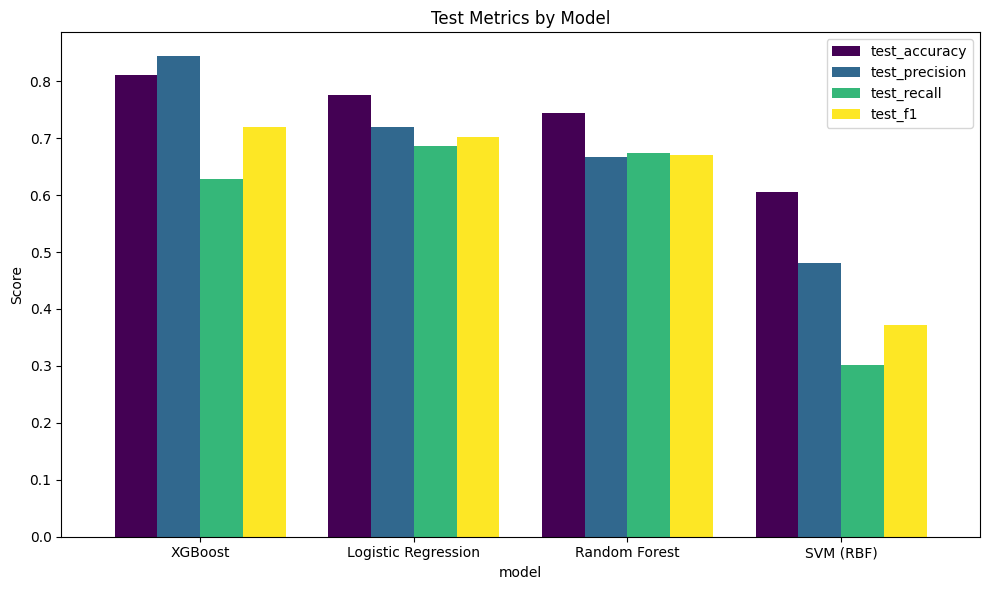

In [7]:
metrics_df = summary_df[["model", "test_accuracy", "test_precision", "test_recall", "test_f1"]].set_index("model")
metrics_df.plot(kind="bar", figsize=(10, 6), width=0.8, colormap="viridis")
plt.title("Test Metrics by Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In the plot we can see that XGBoost outperforms the other models for all metrics except recall, as mentioned above.

Training and Prediction Time plots

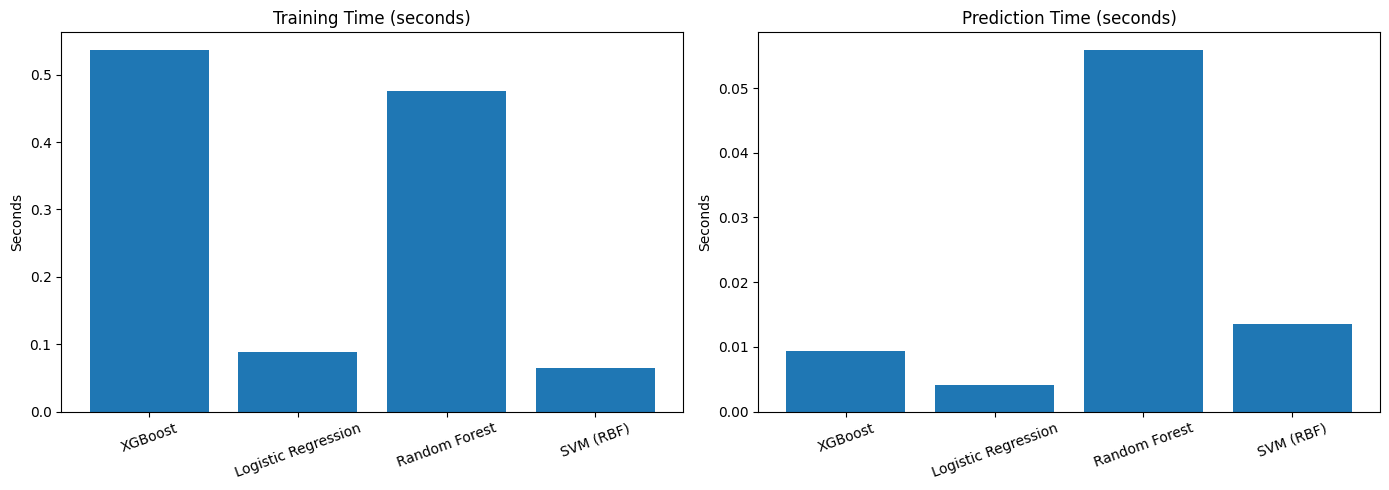

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df["model"], summary_df["fit_time_sec"])
axes[0].set_title("Training Time (seconds)")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis='x', labelrotation=20)

axes[1].bar(summary_df["model"], summary_df["predict_time_sec"])
axes[1].set_title("Prediction Time (seconds)")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.show()

In terms of training time, SVM was the fastest, while XGBoost was the slowest. For prediction time, Logistic Regression was the fastest and Random Forest was the slowest, with XGBoost ranking second.

ROC curves

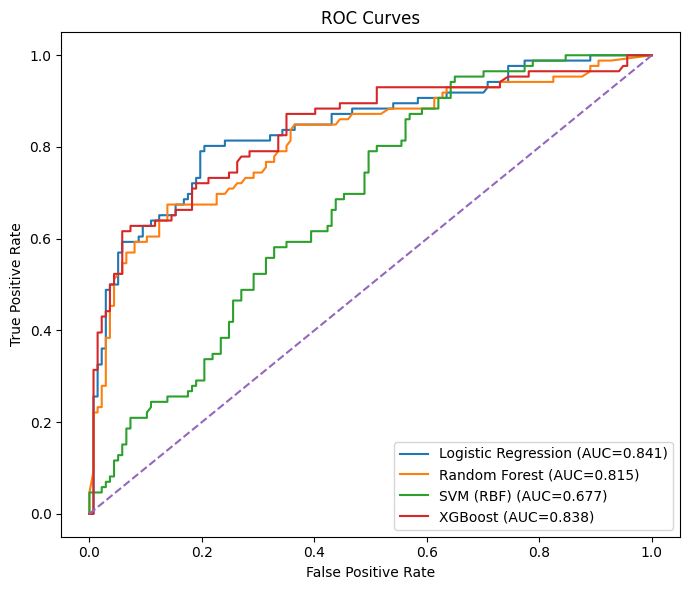

In [9]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


The ROC curves visually confirm that Logistic Regression and XGBoost are the most robust models, with their curves pushing closest to the top-left, and Random Forest following closely behind. The SVM model's curve sits much closer to the 0.5 diagonal, showing its difficulty in distinguishing between the classes.

Confusion matrices

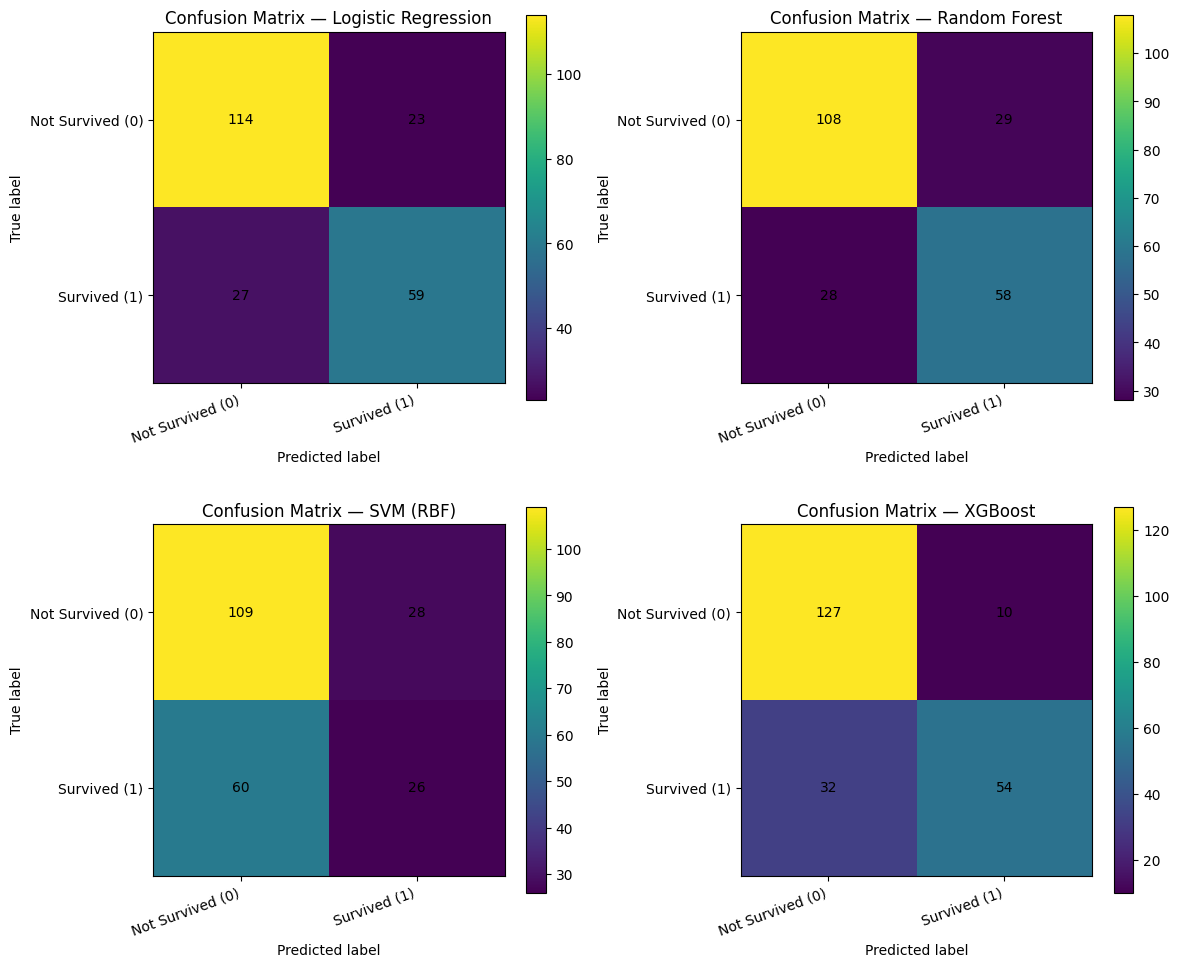

In [10]:
num_models = len(results)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()

classes = ["Not Survived (0)", "Survived (1)"]
tick_marks = np.arange(len(classes))

for idx, r in enumerate(results):
    cm = r["confusion_matrix"]
    name = r["model"]
    ax = axes[idx]
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"Confusion Matrix — {name}")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, rotation=20, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes)
    
    # annotate cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
            )
            
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")

plt.tight_layout()
plt.show()

XGBoost shows the highest precision, being the best in identifying those who did not survive, accurately predicting 127 True Negatives. It is conservative about predicting a survival, resulting in only 10 False Positives (the lowest of any model). However, it missed 32 actual survivors (False Negatives), the highest of the well performing models.

Logistic Regression is the Most Balanced (highest recall), identified the highest number of actual survivors (59 True Positives) and had the lowest False Negatives (27). It generates more False Positives (23) than XGBoost.

Random Forest makes slightly more False Positives (29) and False Negatives (28) than Logistic Regression.

SVM struggles severely, defaulting to the majority class (Not Survived), resulting in a massive 60 False Negatives and only 26 True Positives.

In conclusion, the best model for this task depends on the goal. If the goal is minimizing False Positives, XGBoost is the most suitable model. If the goal is minimizing False Negatives, Logistic Regression could be a better choice.

### -----------------------------
### 7) Discussion
### -----------------------------

Following hyperparameter tuning, XGBoost outperformed all other models in the experiment. It achieved the highest overall test accuracy at 81.17% and a precision score of 84.38%. While Logistic Regression initially performed better when using default parameters, the tuning process allowed XGBoost to improve its performance and achieve the best results.

The effectiveness of XGBoost on this dataset stems from its capacity to model complex, non-linear feature interactions. While traditional Logistic Regression relies on a strict linear assumption, XGBoost employs a sequential learning approach. It constructs an ensemble of decision trees iteratively, with each subsequent tree trained to minimize the residual errors of its predecessors. This progressive correction allows for highly accurate data mapping, which is further stabilized by built-in regularization techniques that reduce overfitting and promote strong generalization.

XGBoost comes with notable computational and performance trade-offs. Computationally, it was the slowest model to train (0.447 seconds), requiring significantly more time than the other models due to the sequential nature of boosting. In terms of performance, while its precision is excellent, its recall dropped to 62.79%. This indicates that the model became conservative, generating very few false alarms, but being prone to False Negatives.